# Phase A assessment story

This notebook tells the Phase A story for one AOI from preprocessing to seasonal interpretation to interval-level land assessment.

It reads the generated backend artifacts directly and presents:
- assessment summary
- confidence breakdown
- explicit gap diagnostics
- smoothed NDVI with detected seasons and grouped gap windows
- supporting smoothed EVI / NDMI / NDWI evidence
- season table, evidence, and risk flags


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'data').exists():
    REPO_ROOT = REPO_ROOT.parent

AOI_ID = 'aoi_demo_01'
RUN_TAG = '_rerun'

ingest_dir = REPO_ROOT / 'data' / AOI_ID
preprocess_candidate = REPO_ROOT / 'data' / 'preprocess' / f'{AOI_ID}{RUN_TAG}'
seasonal_candidate = REPO_ROOT / 'data' / 'seasonal' / f'{AOI_ID}{RUN_TAG}'
assessment_candidate = REPO_ROOT / 'data' / 'assessment' / f'{AOI_ID}{RUN_TAG}'

PREPROCESS_DIR = preprocess_candidate if preprocess_candidate.exists() else REPO_ROOT / 'data' / 'preprocess' / AOI_ID
SEASONAL_DIR = seasonal_candidate if seasonal_candidate.exists() else REPO_ROOT / 'data' / 'seasonal' / AOI_ID
ASSESSMENT_DIR = assessment_candidate if assessment_candidate.exists() else REPO_ROOT / 'data' / 'assessment' / AOI_ID

SMOOTHED_CSV_PATH = PREPROCESS_DIR / 'ndvi_smoothed.csv'
QUALITY_METRICS_PATH = PREPROCESS_DIR / 'quality_metrics.json'
SEASON_PAYLOAD_PATH = SEASONAL_DIR / 'season_windows.json'
ASSESSMENT_PATH = ASSESSMENT_DIR / 'phase_a_assessment.json'
RUN_METADATA_PATH = ingest_dir / 'run_metadata.json'

for required in [SMOOTHED_CSV_PATH, QUALITY_METRICS_PATH, SEASON_PAYLOAD_PATH, ASSESSMENT_PATH, RUN_METADATA_PATH]:
    if not required.exists():
        raise FileNotFoundError(required)

print({
    'preprocess_dir': str(PREPROCESS_DIR.relative_to(REPO_ROOT)),
    'seasonal_dir': str(SEASONAL_DIR.relative_to(REPO_ROOT)),
    'assessment_dir': str(ASSESSMENT_DIR.relative_to(REPO_ROOT)),
})

{'preprocess_dir': 'data\\preprocess\\aoi_demo_01_rerun', 'seasonal_dir': 'data\\seasonal\\aoi_demo_01_rerun', 'assessment_dir': 'data\\assessment\\aoi_demo_01_rerun'}


In [2]:
def merge_gap_windows(windows: pd.DataFrame, merge_threshold_days: float = 5.0) -> pd.DataFrame:
    if windows.empty:
        return windows.copy()

    merged_rows = []
    current = {
        'start_timestamp': windows.iloc[0]['start_timestamp'],
        'end_timestamp': windows.iloc[0]['end_timestamp'],
        'window_count': 1,
        'max_gap_days': float(windows.iloc[0]['gap_days']),
    }

    for _, row in windows.iloc[1:].iterrows():
        separation_days = (row['start_timestamp'] - current['end_timestamp']).total_seconds() / 86400.0
        if separation_days <= merge_threshold_days:
            current['end_timestamp'] = max(current['end_timestamp'], row['end_timestamp'])
            current['window_count'] += 1
            current['max_gap_days'] = max(current['max_gap_days'], float(row['gap_days']))
        else:
            merged_rows.append(current)
            current = {
                'start_timestamp': row['start_timestamp'],
                'end_timestamp': row['end_timestamp'],
                'window_count': 1,
                'max_gap_days': float(row['gap_days']),
            }

    merged_rows.append(current)
    return pd.DataFrame(merged_rows)

In [3]:
with RUN_METADATA_PATH.open('r', encoding='utf-8') as handle:
    run_metadata = json.load(handle)
with QUALITY_METRICS_PATH.open('r', encoding='utf-8') as handle:
    quality_metrics = json.load(handle)
with SEASON_PAYLOAD_PATH.open('r', encoding='utf-8') as handle:
    season_payload = json.load(handle)
with ASSESSMENT_PATH.open('r', encoding='utf-8') as handle:
    assessment_payload = json.load(handle)

df = pd.read_csv(SMOOTHED_CSV_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
usable_df = df[df['is_usable'].astype(str).str.lower() == 'true'].copy()

long_gap_windows = pd.DataFrame(quality_metrics.get('long_gap_windows', []))
if not long_gap_windows.empty:
    long_gap_windows['start_timestamp'] = pd.to_datetime(long_gap_windows['start_timestamp'], utc=True)
    long_gap_windows['end_timestamp'] = pd.to_datetime(long_gap_windows['end_timestamp'], utc=True)
    grouped_gap_windows = merge_gap_windows(long_gap_windows)
else:
    grouped_gap_windows = long_gap_windows.copy()

summary_df = pd.DataFrame([{
    'aoi_id': assessment_payload['aoi_id'],
    'interval_start': assessment_payload['interval']['start_date'],
    'interval_end': assessment_payload['interval']['end_date'],
    'land_status': assessment_payload['land_status'],
    'trend_2y': assessment_payload['trend_2y'],
    'season_count': assessment_payload['season_count'],
    'latest_season': assessment_payload['latest_season_performance']['label'],
    'latest_provisional': assessment_payload['latest_season_performance']['provisional'],
    'confidence': assessment_payload['confidence']['level'],
    'gap_risk': quality_metrics['gap_risk'],
    'long_gap_count': quality_metrics.get('long_gap_count', 0),
}])
summary_df

,aoi_id,interval_start,interval_end,land_status,trend_2y,season_count,latest_season,latest_provisional,confidence,gap_risk,long_gap_count
0,aoi_demo_01,2024-05-13,2026-05-13,active,stable,4,good,False,low,high,14


In [4]:
confidence_components = assessment_payload['confidence'].get('components', {})
confidence_df = pd.DataFrame([{
    'overall': assessment_payload['confidence']['level'],
    'continuity': confidence_components.get('continuity', 'n/a'),
    'season_clarity': confidence_components.get('season_clarity', 'n/a'),
    'signal_strength': confidence_components.get('signal_strength', 'n/a'),
}])
confidence_df

,overall,continuity,season_clarity,signal_strength
0,low,low,high,high


In [5]:
gap_summary_df = pd.DataFrame([{
    'gap_risk': quality_metrics['gap_risk'],
    'gap_ratio': quality_metrics['gap_ratio'],
    'max_gap_days': quality_metrics['max_gap_days'],
    'median_gap_days': quality_metrics['median_gap_days'],
    'long_gap_count': quality_metrics.get('long_gap_count', 0),
    'grouped_gap_band_count': 0 if grouped_gap_windows.empty else len(grouped_gap_windows),
    'gap_reason': quality_metrics['gap_risk_reason'],
}])
gap_summary_df

,gap_risk,gap_ratio,max_gap_days,median_gap_days,long_gap_count,grouped_gap_band_count,gap_reason
0,high,0.246866,24.996968,3.006829,14,9,"Long or frequent gaps may hide season onset, i..."


In [6]:
if long_gap_windows.empty:
    pd.DataFrame([{'note': 'No long gap windows were detected above the configured threshold.'}])
else:
    grouped_gap_windows

In [7]:
risk_flags = assessment_payload['risk_flags']
if risk_flags:
    pd.DataFrame(risk_flags)
else:
    pd.DataFrame([{'code': 'none', 'severity': 'none', 'reason': 'No conservative risk flags were raised.'}])

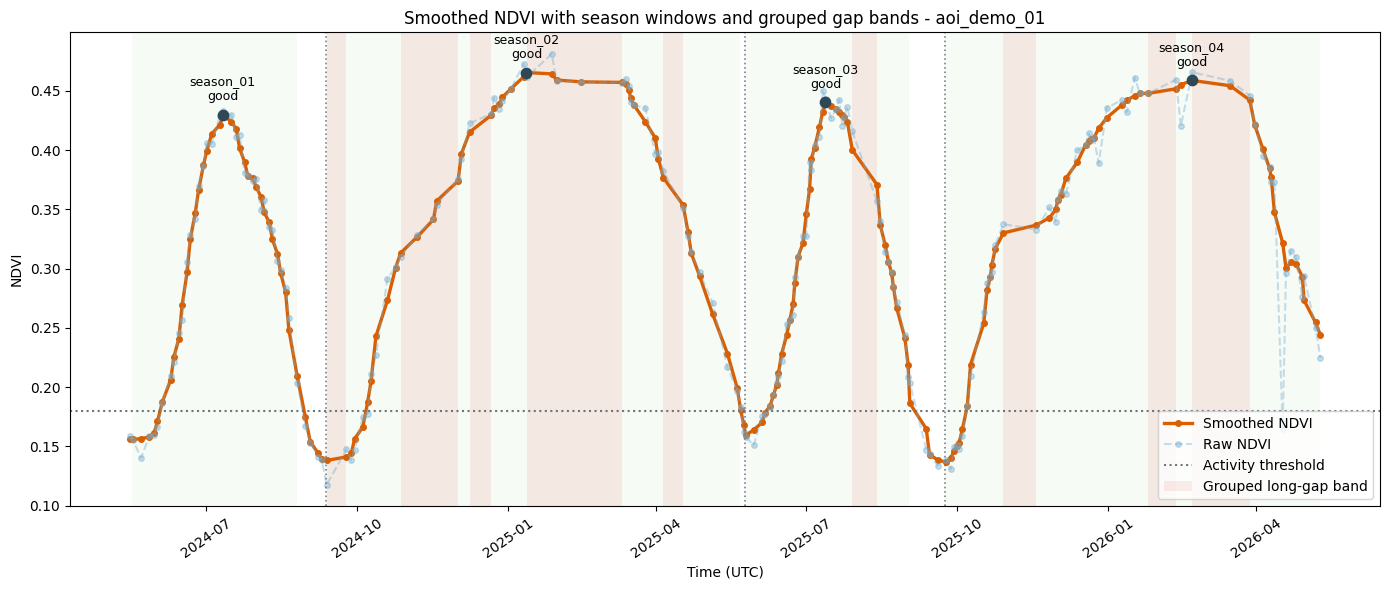

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(usable_df['timestamp'], usable_df['ndvi_smoothed'], color='#d95f02', linewidth=2.4, marker='o', markersize=4, label='Smoothed NDVI')
ax.plot(usable_df['timestamp'], usable_df['ndvi_raw'], color='#74add1', linestyle='--', alpha=0.4, marker='o', markersize=4, label='Raw NDVI')

season_colors = {
    'good': '#d9f0d3',
    'interrupted': '#fee08b',
    'weak': '#fddbc7',
}

for index, season in enumerate(season_payload['seasons']):
    start = pd.Timestamp(season['start_date'], tz='UTC')
    end = pd.Timestamp(season['end_date'], tz='UTC')
    peak = pd.Timestamp(season['peak_date'], tz='UTC')
    color = season_colors.get(season['quality_label'], '#e0e0e0')
    ax.axvspan(start, end, color=color, alpha=0.22, linewidth=0)
    if index > 0:
        ax.axvline(start, color='#6c757d', linestyle=':', linewidth=1.2, alpha=0.9)
    ax.scatter([peak], [season['peak_ndvi']], color='#2f4858', s=55, zorder=3)
    ax.text(peak, season['peak_ndvi'] + 0.01, f"{season['season_id']}\n{season['quality_label']}", fontsize=9, ha='center', va='bottom')

if not grouped_gap_windows.empty:
    for _, window in grouped_gap_windows.iterrows():
        ax.axvspan(window['start_timestamp'], window['end_timestamp'], color='#d73027', alpha=0.09, linewidth=0)

ax.axhline(0.18, color='#6c757d', linestyle=':', linewidth=1.5, label='Activity threshold')
legend_handles, legend_labels = ax.get_legend_handles_labels()
if not grouped_gap_windows.empty:
    legend_handles.append(Patch(facecolor='#d73027', alpha=0.09, edgecolor='none', label='Grouped long-gap band'))
    legend_labels.append('Grouped long-gap band')
ax.legend(legend_handles, legend_labels, loc='best')
ax.set_title(f"Smoothed NDVI with season windows and grouped gap bands - {assessment_payload['aoi_id']}")
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('NDVI')
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

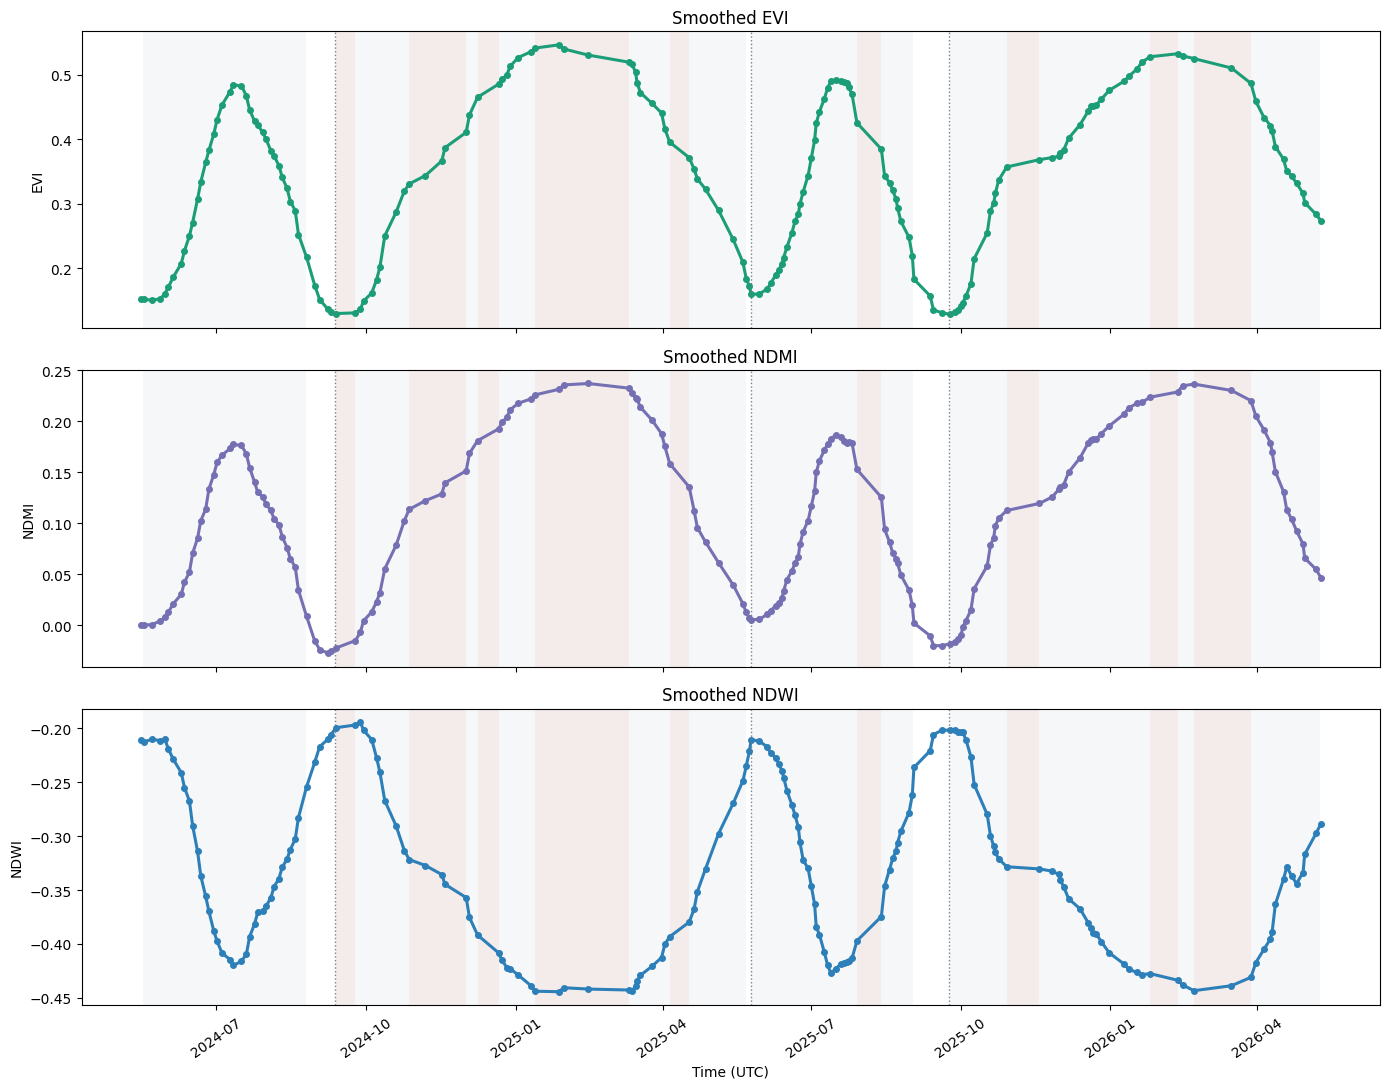

In [9]:
metric_specs = [
    ('evi_smoothed', '#1b9e77', 'Smoothed EVI'),
    ('ndmi_smoothed', '#7570b3', 'Smoothed NDMI'),
    ('ndwi_smoothed', '#2c7fb8', 'Smoothed NDWI'),
]

fig, axes = plt.subplots(len(metric_specs), 1, figsize=(14, 11), sharex=True)
if len(metric_specs) == 1:
    axes = [axes]

for axis, (column, color, title) in zip(axes, metric_specs):
    axis.plot(usable_df['timestamp'], usable_df[column], color=color, linewidth=2.2, marker='o', markersize=4)
    for index, season in enumerate(season_payload['seasons']):
        start = pd.Timestamp(season['start_date'], tz='UTC')
        end = pd.Timestamp(season['end_date'], tz='UTC')
        axis.axvspan(start, end, color='#adb5bd', alpha=0.10, linewidth=0)
        if index > 0:
            axis.axvline(start, color='#6c757d', linestyle=':', linewidth=1.0, alpha=0.9)
    if not grouped_gap_windows.empty:
        for _, window in grouped_gap_windows.iterrows():
            axis.axvspan(window['start_timestamp'], window['end_timestamp'], color='#d73027', alpha=0.06, linewidth=0)
    axis.set_title(title)
    axis.set_ylabel(column.replace('_smoothed', '').upper())

axes[-1].set_xlabel('Time (UTC)')
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

In [10]:
seasons_table = pd.DataFrame([
    {
        'season_id': season['season_id'],
        'start_date': season['start_date'],
        'peak_date': season['peak_date'],
        'end_date': season['end_date'],
        'is_open': season['is_open'],
        'quality_label': season['quality_label'],
        'confirmation_level': season.get('confirmation_level', 'n/a'),
        'gap_overlap_count': season.get('gap_overlap_count', 0),
        'gap_overlap_risk': season.get('gap_overlap_risk', 'low'),
        'gap_overlap_stage': season.get('gap_overlap_stage', 'none'),
        'peak_ndvi': season['peak_ndvi'],
        'duration_days': season['duration_days'],
        'evidence_summary': season['evidence_summary'],
    }
    for season in season_payload['seasons']
])
seasons_table

,season_id,start_date,peak_date,end_date,is_open,quality_label,confirmation_level,gap_overlap_count,gap_overlap_risk,gap_overlap_stage,peak_ndvi,duration_days,evidence_summary
0,season_01,2024-05-17,2024-07-11,2024-08-25,False,good,strong,0,low,none,0.429375,100.00,"Good season: peak_ndvi=0.429, rise_gain=0.273...."
1,season_02,2024-09-12,2025-01-12,2025-05-22,False,good,strong,9,high,multiple,0.465430,251.99,"Good season: peak_ndvi=0.465, rise_gain=0.327...."
2,season_03,2025-05-25,2025-07-13,2025-09-02,False,good,strong,1,high,multiple,0.440226,100.00,"Good season: peak_ndvi=0.440, rise_gain=0.281...."
3,season_04,2025-09-24,2026-02-21,2026-05-10,True,good,strong,4,high,multiple,0.458735,228.01,"Good season: peak_ndvi=0.459, rise_gain=0.322 ..."


In [11]:
evidence_df = pd.DataFrame([{'topic': key, 'detail': value} for key, value in assessment_payload['evidence'].items()])
evidence_df

,topic,detail
0,gap_note,"Long or frequent gaps may hide season onset, i..."
1,land_status_basis,3 recent seasons were detected with active_fra...
2,latest_season_basis,"Good season: peak_ndvi=0.440, rise_gain=0.281...."
3,trend_basis,Season strength stayed within conservative sta...
